# Two Parks, Two Vacant Lots, and 1,254 Votes

In [1]:
import json, re
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import re

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, spearmanr

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#a5a49e"
pd.set_option("display.max_colwidth", 200)
con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers", "incidents", "cannabis"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

# full-text index: meeting_id -> complete minutes text (text layer + vision OCR)
_meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
_sha2mid = {f["sha256"]: mid for mid, m in _meet.items() for f in m["files"]}
_texts = {}
for _tf in Path("../data/interim/text").glob("*.json"):
    _mid = _sha2mid.get(_tf.stem)
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + " ".join(json.loads(_tf.read_text()))
for _of in Path("../data/interim/ocr").glob("*.txt"):
    _mid = _sha2mid.get(_of.name[:64])
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + _of.read_text()
_lower = {m: t.lower() for m, t in _texts.items()}
_dates = {m: v["date"] for m, v in _meet.items()}
lower = _lower
dates = _dates
def mentions(term):
    """Meetings where `term` appears, with counts. Case-insensitive."""
    term = term.lower()
    return pd.DataFrame(
        [(m, _dates[m], _lower[m].count(term)) for m in _lower if term in _lower[m]],
        columns=["meeting_id", "date", "n"],
    ).sort_values("date").reset_index(drop=True)

def context(term, meeting_id, width=200, k=5):
    """Verbatim passages around each occurrence of `term` in one meeting."""
    out = []
    for m in re.finditer(re.escape(term.lower()), _lower[meeting_id]):
        s = max(0, m.start() - width)
        out.append(" ".join(_texts[meeting_id][s : m.end() + width].split()))
        if len(out) >= k:
            break
    return out

print(f"{len(_texts)} meetings indexed, {sum(len(t) for t in _texts.values())/1e6:.0f}M chars")
wf = pd.DataFrame(
    [(m, _meet[m]["date"], _lower[m].count("waterfront")) for m in _lower],
    columns=["meeting_id", "date", "wf_mentions"],
)
wf["date"] = pd.to_datetime(wf.date)
wf_meetings = wf[wf.wf_mentions > 0].sort_values("date").reset_index(drop=True)


110 meetings indexed, 31M chars


![Bushwick Inlet Park from the community center's green roof, April 2026: the soccer field in use on the left - and one of the two vacant lots on the right. Photo: author](images/bip_and_lots.jpg)


::: {.tldr}
**TLDR:** The vacant waterfront lots in north Williamsburg high value and underutilized. I dug into the local community board meeting notes and learned about the history here and how the local community could enact change.

In 10 years of Community Board 1 meeting notes, the local advisory board for North Brooklyn, community turnout never clearly and directly impacted a single land use vote. Community outreach correlates with binding conditions attached to approvals.
:::



## The Backstory

There's a long backstory to the North Brooklyn waterfront. Over the last 20+ years this neighborhood has changed a lot. Williamsburg used to be home to  local industry, for example my apartment building used to be a zipper factory. Currently Williamsburg is dominated by luxury condos and retail. The waterfront was owned by a combination of the city, state, and private owners. In 2005 then-Mayor Bloomberg made a deal to rezone the north Brooklyn waterfront. The plan allowed the building of luxury high rise residential towers, increasing land value for private owners, and promised a waterfront park for the growing community. Since then, the waterfront luxury high rises have been built and continue to go up. Yet - we are stuck with only a portion of the promised 28 acre park (TOOD check size is accurate). 

It's been two decades, where's our park?

![Navy airplanes over Greenpoint, May 1930. The piers, rail yards, and tank farms below are the land in focus for this article. Photo: [U.S. National Archives](https://commons.wikimedia.org/wiki/File:New_York_-_Brooklyn_-_NARA_-_68145045.jpg), public domain](images/aerial_1930_web.jpg)

I was curious how the community can show up and make change happen. There are several community organizations focused on advocacy for different parts of the waterfront: Friends of Bushwick Inlet Park, North Brooklyn Neighbors, North Brooklyn Parks Alliance, Brooklyn Greenway Initiative, Newtown Creek Alliance, Friends of WNYC Transmitter Park. I wanted to get a sense of how these organizations show up and make their voices heard by the local government. In doing so learned that this land is governed by Brooklyn Community Board 1 (CB1), the local advisory board for Williamsburg and Greenpoint. Every land use application has to come through it for a public hearing and a recommendation before the city decides.

## Scraping the minutes

CB1 posts its meeting minutes online. I created an automated script (code linked below) to scrape the pdfs and build a dataset of the key datapoints for these meetings.

The dataset covers all of CB1's 110 meetings, 1,254 votes, and 1,369 speakers. The analysis will focus on the 97 meetings where the term 'waterfront' appears.

Each record is categorized by subject - land use, liquor, parks, environment, transportation, budget. These buckets loosely mirror the board's own committee structure, but I labeled each motion via LLM.

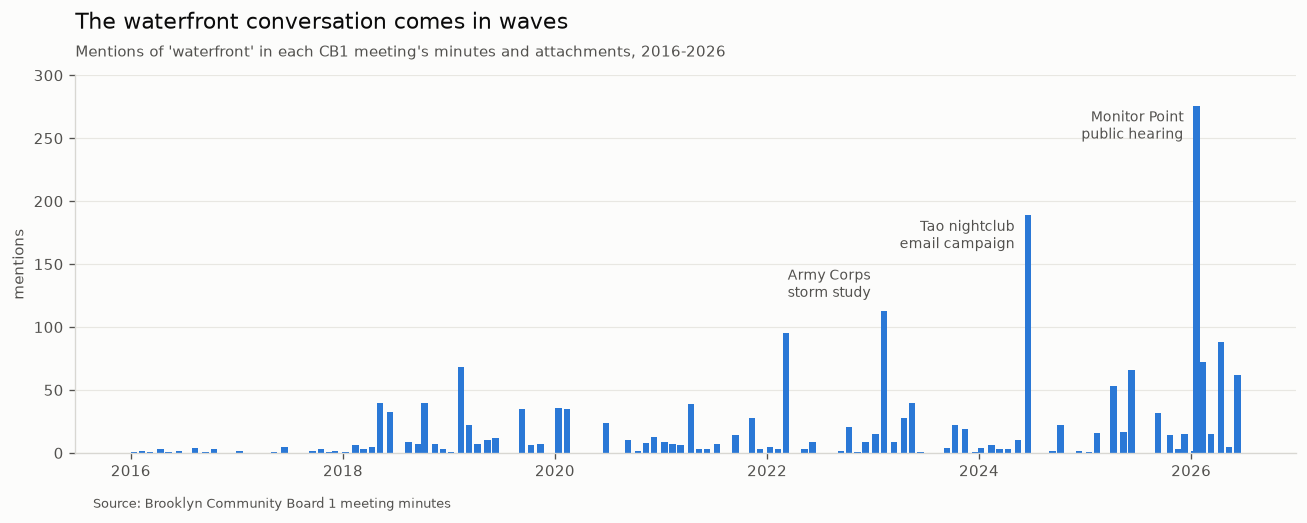

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.2), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.bar(wf_meetings.date, wf_meetings.wf_mentions, width=22, color=BLUE)
for d, v, label in [("2026-01-20", 276, "Monitor Point\npublic hearing"),
                    ("2024-06-18", 189, "Tao nightclub\nemail campaign"),
                    ("2023-02-07", 113, "Army Corps\nstorm study")]:
    ax.annotate(label, (pd.Timestamp(d), v),
                xytext=(-8, 26 if "Army" in label else -2),
                textcoords="offset points", ha="right", va="top",
                fontsize=8.5, color=INK2)
ax.set_ylim(0, 300)
ax.set_ylabel("mentions", fontsize=9, color=INK2)
ax.tick_params(colors=INK2, labelsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#d8d7d2"); ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="y", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("The waterfront conversation comes in waves",
             fontsize=13, color=INK, loc="left", pad=28)
ax.text(0, 1.05, "Mentions of 'waterfront' in each CB1 meeting's minutes and attachments, 2016-2026",
        transform=ax.transAxes, fontsize=9, color=INK2)
fig.text(0.075, -0.02, "Source: Brooklyn Community Board 1 meeting minutes",
         fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

You can see that the term waterfront shows up frequently, with a few spikes in activity. A few highlights with details of what was discussed:

January 20, 2026 — 276 mentions. This is a public hearing focused exclusively on Monitor Point. The notes are mostly written testimony from individuals and community groups including Veronica Zapasnik, a Polish immigrant who's been in the neighborhood since 1990, and NYSAFAH (the New York State Association for Affordable Housing). The opposition testimony repeats one claim: the rezoning of this land into a set of residential towers breaks a two-decade-old promise to make this land into a waterfront park for all.

June 18, 2024 — 189 mentions. There is a swarm of emails to the board about the proposal to open a Tao nightclub next to Bushwick Inlet Park, including one template that was re-sent over 100 times. The letter focuses on the habitat restoration at the Inlet and the noise pollution a club would bring.

February 7, 2023 — 113 mentions. The meeting notes include a document from the Army Corps of Engineers discussing plans for storm mitigation in North Brooklyn.

## What does the board actually fight about?

First question: does the board ever actually disagree? Do votes get contested - and over what?

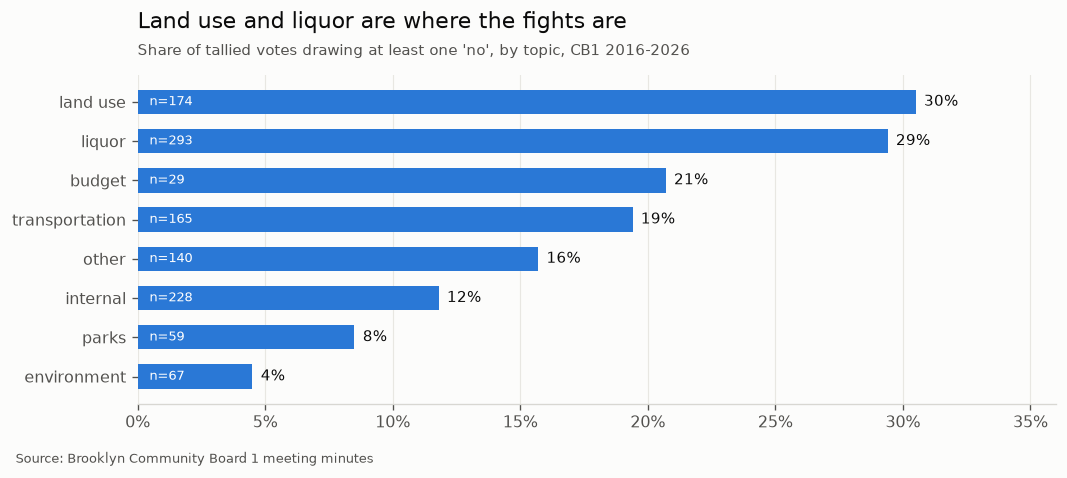

In [3]:
rates = q("""
    SELECT topic_category, count(*) AS n,
           round(avg(CASE WHEN no > 0 THEN 1 ELSE 0 END), 3) AS contested_rate,
           round(stddev_samp(CASE WHEN no > 0 THEN 1 ELSE 0 END), 3) AS std_dev
    FROM votes WHERE yes + no > 0
    GROUP BY 1 ORDER BY contested_rate DESC
""")
NAMES = {"land_use": "land use"}
r = rates.assign(topic=rates.topic_category.map(lambda t: NAMES.get(t, t))).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 3.8), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.barh(r.topic, r.contested_rate, height=0.62, color=BLUE)
for y, (rate, n) in enumerate(zip(r.contested_rate, r.n)):
    ax.annotate(f"{rate:.0%}", (rate, y), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
    ax.annotate(f"n={n}", (0.002, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=7.5, color="#ffffff")
ax.set_xlim(0, 0.36)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.tick_params(colors=INK2, labelsize=9.5)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="x", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("Land use and liquor are where the fights are",
             fontsize=13, color=INK, loc="left", pad=28)
ax.text(0, 1.06, "Share of tallied votes drawing at least one 'no', by topic, CB1 2016-2026",
        transform=ax.transAxes, fontsize=9, color=INK2)
fig.text(0.02, -0.03, "Source: Brooklyn Community Board 1 meeting minutes",
         fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

The above graphic plots the share of votes in each topic drawing at least one 'no'. This is a simple way to measure how often the board splits on a motion. Looking at the park and environment votes - we see that these votes are rarely contested at 8% and 4% respectively. It turns out that most of the debate around the park development actually happens in 'land use' votes and we see those votes are heavily contested. 30% of votes on land use draw at least one 'no' vote.

So land use votes draw debate, but can we find out why? What data points would help us predict a contested vote?

turnout (log speakers): OR 1.227, p=0.105 (n=1150)
land use only: p=0.976 (n=172)


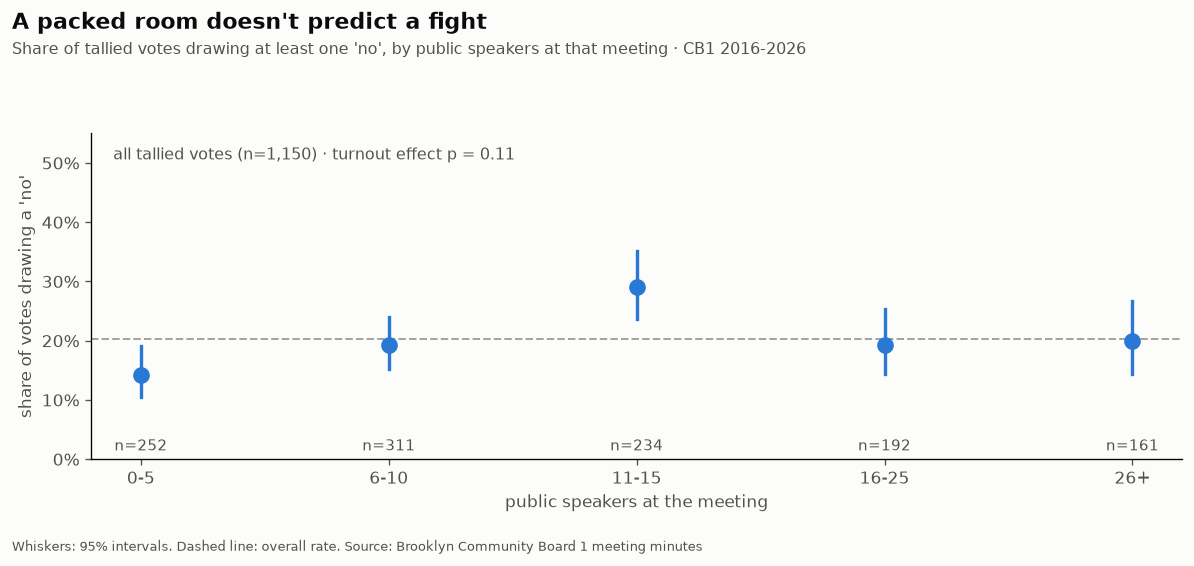

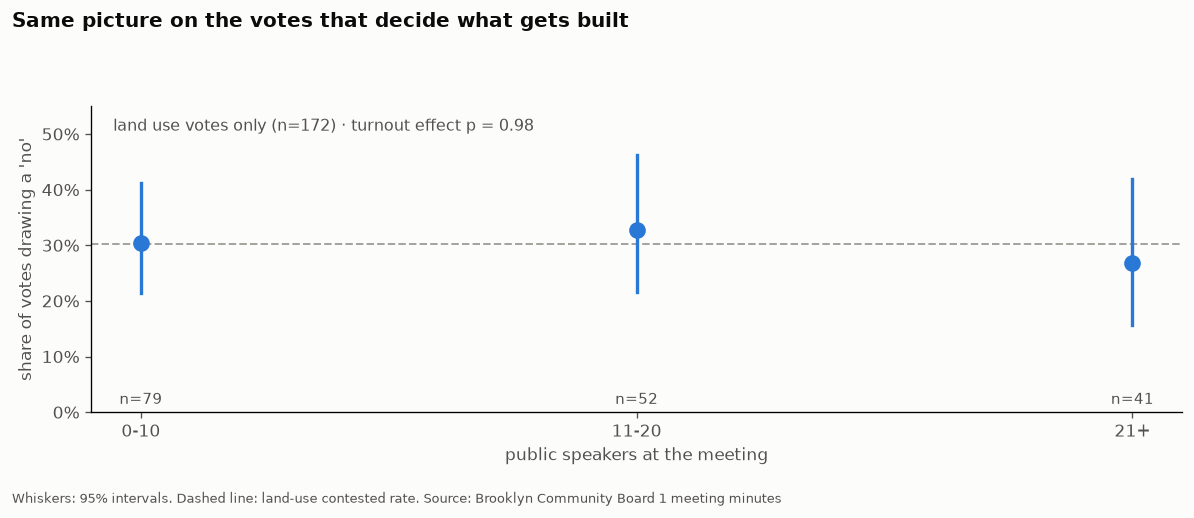

In [4]:
# Does turnout predict a contested vote? Logistic regression over all tallied
# votes (errors clustered by meeting). Top: the picture — contested share by
# how many people spoke at that meeting. Bottom: the model's odds ratios.
from statsmodels.stats.proportion import proportion_confint

reg = q("""
    SELECT v.meeting_id, v.topic_category, v.no,
           m.attendance_count, year(m.date) AS yr,
           (SELECT count(*) FROM speakers s WHERE s.meeting_id = v.meeting_id) AS n_speakers,
           (SELECT count(*) FROM speakers s WHERE s.meeting_id = v.meeting_id
              AND s.position IN ('for','against')) AS n_pos_speakers
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.yes + v.no > 0
""").dropna(subset=["attendance_count"])
reg["contested"] = (reg.no > 0).astype(int)

fit = smf.logit(
    "contested ~ np.log1p(n_speakers) + C(topic_category, Treatment('liquor'))"
    " + attendance_count + I(yr-2016)",
    data=reg,
).fit(disp=0, cov_type="cluster", cov_kwds={"groups": reg.meeting_id})
p_turnout = fit.pvalues["np.log1p(n_speakers)"]
print(f"turnout (log speakers): OR {np.exp(fit.params['np.log1p(n_speakers)']):.3f}, "
      f"p={p_turnout:.3f} (n={len(reg)})")

lu = reg[reg.topic_category == "land_use"]
f_lu = smf.logit("contested ~ np.log1p(n_speakers) + attendance_count + I(yr-2016)",
                 data=lu).fit(disp=0, cov_type="cluster", cov_kwds={"groups": lu.meeting_id})
p_lu = f_lu.pvalues["np.log1p(n_speakers)"]
print(f"land use only: p={p_lu:.3f} (n={len(lu)})")

def buckets(d, edges, labels):
    out = []
    grp = pd.cut(d.n_speakers, edges, labels=labels)
    for lab, g in d.groupby(grp, observed=True):
        k, n = g.contested.sum(), len(g)
        lo, hi = proportion_confint(k, n, method="wilson")
        out.append((lab, n, k / n, lo, hi))
    return out

def bucket_axis(ax, bk, base, note):
    ax.set_facecolor(SURFACE)
    xs = range(len(bk))
    ax.axhline(base, color=GRAY, lw=1.2, ls="--", zorder=1)
    for x, (lab, n, p, lo, hi) in zip(xs, bk):
        ax.plot([x, x], [lo, hi], color=BLUE, lw=2, zorder=2)
        ax.plot(x, p, "o", color=BLUE, ms=9, zorder=3)
        ax.annotate(f"n={n}", (x, 0.015), ha="center", fontsize=9, color=INK2)
    ax.set_xticks(list(xs), [b[0] for b in bk], fontsize=10)
    ax.annotate(note, (0.02, 0.92), xycoords="axes fraction", fontsize=9.5, color=INK2)
    ax.annotate(f"overall rate {base:.0%}", (len(bk) - 0.55, base + 0.02),
                ha="right", fontsize=9, color=INK2)
    ax.set_ylim(0, 0.55)
    ax.set_ylabel("share of votes drawing a 'no'", fontsize=10, color=INK2)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.set_xlabel("public speakers at the meeting", fontsize=10, color=INK2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=INK2)

SRC = "Source: Brooklyn Community Board 1 meeting minutes"

# --- figure 1: all tallied votes ---
fig, ax = plt.subplots(figsize=(10, 4.4), dpi=120)
fig.patch.set_facecolor(SURFACE)
bucket_axis(ax, buckets(reg, [-1, 5, 10, 15, 25, 999],
                        ["0-5", "6-10", "11-15", "16-25", "26+"]),
            reg.contested.mean(), f"all tallied votes (n={len(reg):,}) · turnout effect p = {p_turnout:.2f}")
fig.suptitle("A packed room doesn't predict a fight", fontsize=13, color=INK,
             x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.9, "Share of tallied votes drawing at least one 'no', by public speakers "
         "at that meeting · CB1 2016-2026", fontsize=9.5, color=INK2)
fig.text(0.01, -0.02, "Whiskers: 95% intervals. Dashed line: overall rate. " + SRC,
         fontsize=8, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()

# --- figure 2: land use only ---
fig, ax = plt.subplots(figsize=(10, 4.0), dpi=120)
fig.patch.set_facecolor(SURFACE)
bucket_axis(ax, buckets(lu, [-1, 10, 20, 999], ["0-10", "11-20", "21+"]),
            lu.contested.mean(), f"land use votes only (n={len(lu)}) · turnout effect p = {p_lu:.2f}")
fig.suptitle("Same picture on the votes that decide what gets built", fontsize=12,
             color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, -0.02, "Whiskers: 95% intervals. Dashed line: land-use contested rate. " + SRC,
         fontsize=8, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

I ran a regression to find out the relationship between the number of public speakers and the likelihood of a contested vote. Across all 1,150 tallied votes, controlling for topic, attendance, and year, with errors clustered by meeting, the strongest predictor of a contested vote is the topic of the vote. The number of public speakers at a meeting has no significant relationship with whether a vote that night draws a 'no', even when counting only speakers who took a side. A contested vote is just as likely at a quiet meeting as at a packed one.

This analysis was done using a logistic regression that predicts whether a vote draws at least one 'no'. The inputs are the vote's topic, the number of public speakers at that meeting, the board's attendance, and the year. I clustered votes by meeting as a way to control for one meeting having more divisive votes than another meeting. Division is the outcome here because it's the clearest signal in the record: a 'no' means somebody on the board pushed back. The alternative - checking whether the board voted the way the community asked - doesn't work with minutes data, because many motions exist precisely because the community asked for them. A unanimous 'yes' can't separate a board that was persuaded from a board that already agreed.

The two charts above show the raw data: the share of contested votes at meetings with increasing amounts of public speakers. The buckets hug the average and the intervals overlap, showing no clear effect of more public speakers on CB1 discord.

/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/bradlowenstein/Workspace/local_govt/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


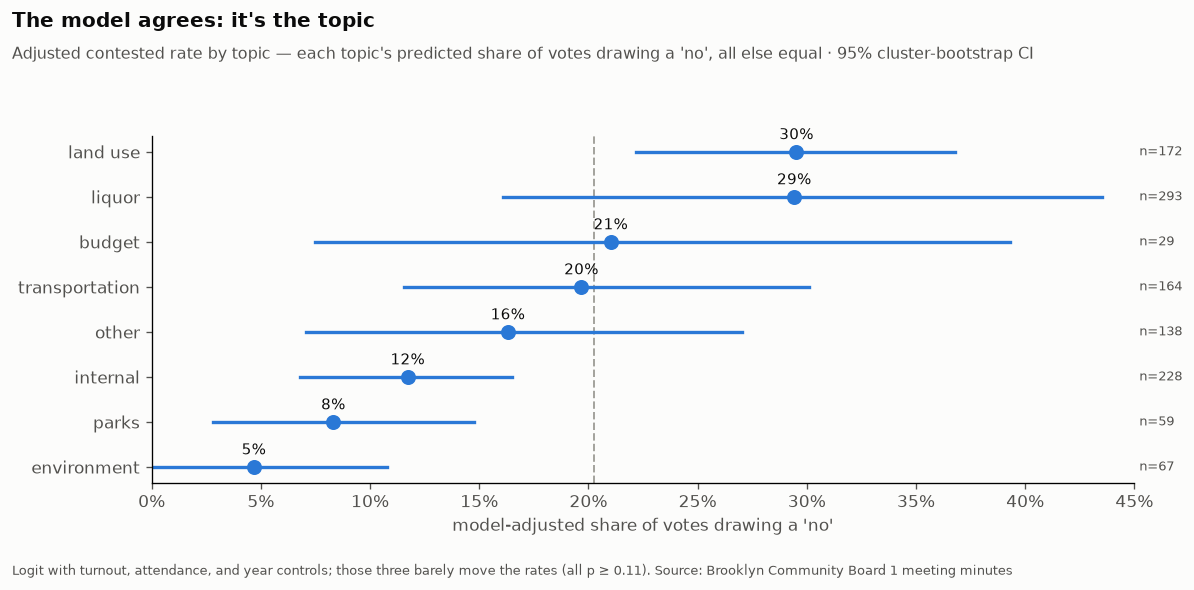

In [5]:
# --- figure 3: adjusted contested rate by topic (no baseline needed) ---
# G-computation: for each topic, set every vote's topic to it and average the
# model's predicted contested probability. CIs from a cluster bootstrap
# (resampling meetings), so the uncertainty respects within-meeting correlation.
rng = np.random.default_rng(11)
meetings_list = reg.meeting_id.unique()
topics = sorted(reg.topic_category.unique())

def adjusted_rates(d):
    f = smf.logit(
        "contested ~ np.log1p(n_speakers) + C(topic_category)"
        " + attendance_count + I(yr-2016)", data=d).fit(disp=0)
    out = {}
    for t in topics:
        cf = d.copy()
        cf["topic_category"] = t
        out[t] = f.predict(cf).mean()
    return out

point = adjusted_rates(reg)
boot = {t: [] for t in topics}
for _ in range(300):
    sample_ids = rng.choice(meetings_list, size=len(meetings_list), replace=True)
    bs = pd.concat([reg[reg.meeting_id == m] for m in sample_ids], ignore_index=True)
    if bs.topic_category.nunique() < len(topics):
        continue
    try:
        r = adjusted_rates(bs)
    except Exception:
        continue
    for t in topics:
        boot[t].append(r[t])

order = sorted(topics, key=lambda t: point[t])
fig, ax = plt.subplots(figsize=(10, 4.6), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.axvline(reg.contested.mean(), color=GRAY, lw=1.2, ls="--", zorder=1)
for yy, t in enumerate(order):
    lo, hi = np.percentile(boot[t], [2.5, 97.5])
    ax.plot([lo, hi], [yy, yy], color=BLUE, lw=2, zorder=2)
    ax.plot(point[t], yy, "o", color=BLUE, ms=8, zorder=3)
    n_t = (reg.topic_category == t).sum()
    ax.annotate(f"{point[t]:.0%}", (point[t], yy + 0.28), ha="center", fontsize=9, color=INK)
    ax.annotate(f"n={n_t}", (1.005, yy), xycoords=("axes fraction", "data"),
                fontsize=8, color=INK2, va="center")
ax.set_yticks(range(len(order)), [t.replace("_", " ") for t in order], fontsize=10)
ax.annotate(f"overall {reg.contested.mean():.0%}",
            (reg.contested.mean() + 0.005, len(order) - 0.4), fontsize=8.5, color=INK2)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlim(0, 0.45)
ax.set_xlabel("model-adjusted share of votes drawing a 'no'", fontsize=10, color=INK2)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=INK2)
fig.suptitle("The model agrees: it's the topic", fontsize=12, color=INK, x=0.01,
             ha="left", fontweight="bold")
fig.text(0.01, 0.895, "Adjusted contested rate by topic — each topic's predicted share of "
         "votes drawing a 'no', all else equal · 95% cluster-bootstrap CI",
         fontsize=9.5, color=INK2)
fig.text(0.01, -0.02, "Logit with turnout, attendance, and year controls; those three "
         "barely move the rates (all p \u2265 0.11). " + SRC,
         fontsize=8, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.87])
plt.show()

This chart is the model's answer for each topic: the contested rate that topic would produce if it were the only thing on the calendar, with turnout, attendance, and year held where they actually were. Land use comes out at 30% and liquor at 29%. Parks is 8%. Environment is 5%. The gap between the top and bottom of that chart is the finding - the subject of a vote sets the odds of a fight before anyone signs up to speak.

So turnout doesn't correlate with division the way the board votes. What impact does the community have then?

## Showing up - at the mic and in writing

Our dataset of CB1 meetings contain datapoints on two main ways the community can show up: public speakers and written testimony. 


In [6]:
import json
from pathlib import Path

_meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
BOUND = re.compile(
    r"From: [A-Z][A-Za-z .\u2019'-]{3,40}? Sent: |"
    r"Dear (?:Chair|Chairperson|Community Board|CB ?1|Members|Board|Mr\.|Ms\.|"
    r"Sir|Madam|District Manager)|To Whom It May Concern", re.I)
WFC = re.compile(r"bushwick inlet|monitor point|river ring|quay|65 commercial|"
                 r"waterfront|esplanade|demapp|inlet park|marsha p", re.I)

_ocr = {}
for _of in Path("../data/interim/ocr").glob("*.txt"):
    sha, p = _of.stem.rsplit("-p", 1)
    _ocr.setdefault(sha, []).append((int(p), _of))

rows = []
for mid, m in _meet.items():
    att = ""
    for f in m["files"]:
        sha = f["sha256"]
        sf = Path(f"../data/interim/segments/{sha}.json")
        if not sf.exists():
            continue
        body = set(json.loads(sf.read_text())["body_pages"])
        tp = Path(f"../data/interim/text/{sha}.json")
        pages = json.loads(tp.read_text()) if tp.exists() else []
        att += " ".join(p for i, p in enumerate(pages) if i not in body)
        for pno, of in _ocr.get(sha, []):
            if pno not in body:
                att += " " + of.read_text()
    t = " ".join(att.split())
    idxs = [b.start() for b in BOUND.finditer(t)]
    wf_items = 0
    for j, st in enumerate(idxs):
        end = idxs[j + 1] if j + 1 < len(idxs) else min(st + 1500, len(t))
        if WFC.search(t[st:end]):
            wf_items += 1
    rows.append({"date": pd.Timestamp(m["date"]), "n_virtual": wf_items})
corr_pm = pd.DataFrame(rows).query("n_virtual > 0").sort_values("date")
#print(f"{corr_pm.n_virtual.sum()} waterfront written comments across "
 #f     f"{len(corr_pm)} meetings (packets include correspondence from ~2022)")

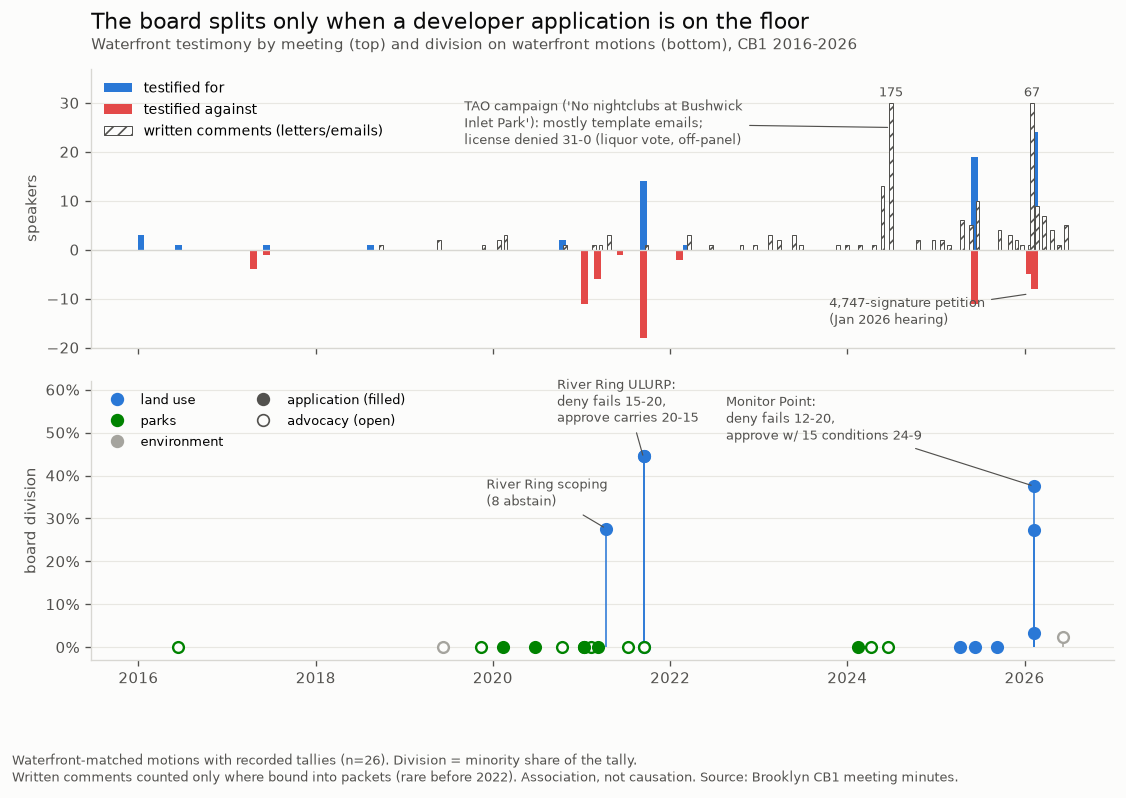

In [7]:
# waterfront votes: matcher + features (also used by the votes table below)
WF = ("(bushwick inlet|monitor point|river ring|quay|65 commercial|56 quay|"
      "40 quay|waterfront|esplanade|demapp|marsha p|inlet park|fbip|open space)")

wfv = q(f"""
    SELECT v.meeting_id, m.date, v.motion_text, v.topic_category,
           v.yes, v.no, v.abstain, v.outcome, len(v.conditions) AS num_conditions_attached
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.topic_category IN ('land_use','parks','environment')
      AND regexp_matches(lower(v.motion_text), '{WF}')
      AND NOT regexp_matches(lower(v.motion_text), 'link5g')
      AND v.yes + v.no > 0
    ORDER BY date
""")
tot = wfv.yes + wfv.no + wfv.abstain
wfv["division"] = (tot - wfv[["yes", "no"]].max(axis=1)) / tot
APP = re.compile(r"application|ulurp|ceqr|proposal|scoping|design|demapp", re.I)
wfv["kind"] = wfv.motion_text.map(
    lambda t: "application" if APP.search(t) else "advocacy")
wfv["date"] = pd.to_datetime(wfv.date)

per_meet = q(f"""
    SELECT m.date,
           count(*) FILTER (s.position = 'for') AS n_for,
           count(*) FILTER (s.position = 'against') AS n_against
    FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF}')
    GROUP BY 1 ORDER BY 1
""")
per_meet["date"] = pd.to_datetime(per_meet.date)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 6.4), dpi=120, sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})
fig.patch.set_facecolor(SURFACE)
W = 28  # bar width, days
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color("#d8d7d2")
    ax.spines["bottom"].set_color("#d8d7d2")
    ax.tick_params(colors=INK2, labelsize=9)

ax1.bar(per_meet.date, per_meet.n_for, width=W, color=BLUE, label="testified for")
ax1.bar(per_meet.date, -per_meet.n_against, width=W, color=RED,
        label="testified against")
VBAR = corr_pm.set_index("date").n_virtual
ax1.bar(VBAR.index + pd.Timedelta(days=11), VBAR.clip(upper=30), width=W * 0.55,
        facecolor=SURFACE, edgecolor=INK2, hatch="///", lw=0.6,
        label="written comments (letters/emails)")
for d, nv in VBAR[VBAR > 30].items():
    ax1.annotate(f"{nv}", (d + pd.Timedelta(days=11), 30.7), ha="center",
                 va="bottom", fontsize=8, color=INK2)
ax1.set_ylim(-20, 37)
ax1.axhline(0, color="#d8d7d2", lw=0.8)
ax1.set_ylabel("speakers", fontsize=9, color=INK2)
ax1.legend(loc="upper left", frameon=False, fontsize=8.5)
ax1.grid(axis="y", color="#e8e7e2", lw=0.7)
ax1.set_axisbelow(True)
ax1.annotate("4,747-signature petition\n(Jan 2026 hearing)",
             (pd.Timestamp("2026-01-20"), -9), xytext=(-120, -18),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.annotate("TAO campaign ('No nightclubs at Bushwick\nInlet Park'): mostly template emails;\nlicense denied 31-0 (liquor vote, off-panel)",
             (pd.Timestamp("2024-06-29"), 25), xytext=(-256, -10),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.set_title("The board splits only when a developer application is on the floor",
              fontsize=13, color=INK, loc="left", pad=24)
ax1.text(0, 1.07, "Waterfront testimony by meeting (top) and division on waterfront motions (bottom), CB1 2016-2026",
         transform=ax1.transAxes, fontsize=9, color=INK2)

GREEN = "#008300"
TOPIC_COLOR = {"land_use": BLUE, "parks": GREEN, "environment": GRAY}
for (topic, kind), g in wfv.groupby(["topic_category", "kind"]):
    color = TOPIC_COLOR[topic]
    face = color if kind == "application" else SURFACE
    ax2.vlines(g.date, 0, g.division, color=color, lw=1.2, alpha=0.8)
    ax2.scatter(g.date, g.division, s=42, facecolor=face, edgecolor=color,
                lw=1.4, zorder=3)
ax2.set_ylabel("board division", fontsize=9, color=INK2)
ax2.set_ylim(-0.03, 0.62)
ax2.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
from matplotlib.lines import Line2D
handles = [
    Line2D([], [], marker="o", ls="", mfc=BLUE, mec=BLUE, ms=7, label="land use"),
    Line2D([], [], marker="o", ls="", mfc=GREEN, mec=GREEN, ms=7, label="parks"),
    Line2D([], [], marker="o", ls="", mfc=GRAY, mec=GRAY, ms=7, label="environment"),
    Line2D([], [], marker="o", ls="", mfc=INK2, mec=INK2, ms=7, label="application (filled)"),
    Line2D([], [], marker="o", ls="", mfc=SURFACE, mec=INK2, ms=7, label="advocacy (open)"),
]
ax2.legend(handles=handles, loc="upper left", frameon=False, fontsize=8, ncol=2)
ax2.grid(axis="y", color="#e8e7e2", lw=0.7)
ax2.set_axisbelow(True)
ax2.annotate("River Ring scoping\n(8 abstain)", (pd.Timestamp("2021-04-13"), 0.276),
             xytext=(-72, 14), textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("River Ring ULURP:\ndeny fails 15-20,\napprove carries 20-15",
             (pd.Timestamp("2021-09-14"), 0.44), xytext=(-52, 22),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("Monitor Point:\ndeny fails 12-20,\napprove w/ 15 conditions 24-9",
             (pd.Timestamp("2026-02-10"), 0.375), xytext=(-185, 28),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
fig.text(0.065, -0.01,
         "Waterfront-matched motions with recorded tallies (n=26). Division = minority share of the tally.\n"
         "Written comments counted only where bound into packets (rare before 2022). "
         "Association, not causation. Source: Brooklyn CB1 meeting minutes.",
         fontsize=8, color=INK2, va="top")
plt.show()

In [8]:
wfs = q(f"""
    SELECT m.date, s.position FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF}')
""")
wfs["date"] = pd.to_datetime(wfs.date)
wfv["spk90"] = wfv.date.map(
    lambda d: ((d - wfs.date).dt.days.between(0, 90)).sum())

disp = wfv.sort_values("date").copy()
disp["Meeting"] = disp.date.dt.strftime("%b %Y")
disp["Motion"] = disp.motion_text.str.slice(0, 60).str.strip() + \
    disp.motion_text.str.len().gt(60).map({True: "...", False: ""})
disp["Type"] = disp.kind
disp["Topic"] = disp.topic_category.str.replace("_", " ")
disp["Vote (yes-no-abstain)"] = (disp.yes.astype(str) + "-" + disp.no.astype(str)
                                 + "-" + disp.abstain.astype(str))
disp["Board division"] = (disp.division * 100).round().astype(int).astype(str) + "%"
disp["Conditions attached"] = disp.num_conditions_attached
disp["Speakers, prior 90 days"] = disp.spk90
from IPython.display import HTML
_tbl = disp[["Meeting", "Motion", "Type", "Vote (yes-no-abstain)",
             "Board division", "Conditions attached", "Speakers, prior 90 days"]] \
    .to_html(index=False, border=0, classes=["table", "table-sm", "table-striped"])
HTML("<details open><summary><strong>The 26 votes behind the chart</strong>"
     "</summary>"
     "<div class='vote-scroll' style='max-height:420px;overflow-y:auto;"
     "border:1px solid #dee2e6;border-radius:4px;margin-top:0.5em;'>"
     + _tbl +
     "</div><style>.vote-scroll thead th{position:sticky;top:0;"
     "background:#fff;box-shadow:0 1px 0 #dee2e6;}</style></details>")

Meeting,Motion,Type,Vote (yes-no-abstain),Board division,Conditions attached,"Speakers, prior 90 days"
Jun 2016,Motion to have the Parks Department move forward with the Bu...,advocacy,39-0-0,0%,0,1
Jun 2019,Send a letter to the Parks Department and EDC requesting air...,advocacy,36-0-0,0%,0,0
Nov 2019,Motion to send a letter of support for the Friends of Bushwi...,advocacy,38-0-0,0%,0,0
Feb 2020,Motion to support the committee's recommendation to reject t...,application,33-0-0,0%,6,0
Jun 2020,Approval of the Parks & Waterfront Committee's Report RE: Re...,application,28-0-0,0%,0,0
Oct 2020,Motion to send a letter requesting that the Parks Department...,advocacy,29-0-0,0%,0,2
Jan 2021,Support the Parks & Waterfront Committee recommendation rega...,application,47-0-0,0%,1,11
Jan 2021,Support the Parks & Waterfront Committee recommendation rega...,advocacy,47-0-0,0%,1,11
Feb 2021,Send letter to NYS Parks and state elected officials regardi...,advocacy,30-0-0,0%,0,12
Mar 2021,Support the Parks & Waterfront Committee's amended resolutio...,application,30-0-0,0%,4,19


The above charts show the community involvement (top) and the board's votes (bottom). From 2016 to 2020 there's minimal community involvement and zero contentious votes - waterfront advocacy motions pass unanimously, year after year. Later on we see two large spikes in CB1 vote division: the first being the River Ring cluster with two contested votes in 2021, the second the Monitor Point vote in 2026. Both of these voting events are clearly correlated with testimony spikes in the top chart.

There are 2 takeaways here. First, turnout is not one-sided: at the Monitor Point vote in February 2026 the public testimony ran 24 in favor vs 8 against - union members turned out for the project - while a 4,747-signature petition ran against it. "Community involvement" was on both sides of the room. Second, written testimony grows over time. The hatched bars in the top chart show the written testimony. At the January 2026 hearing only 5 people spoke at the mic, but the meeting notes contain 67 written comments. Over time we start seeing more written community involvement. It's hard to say if this data point is valid or just an artifact of the board minutes including more written testimony over time as digital records became easier to process.

Another interesting data point is the nightclub vote. I see this as the one outright win for advocates of the park. It's missing from the bottom chart because it was a liquor license vote and the chart only tracks land use. In 2024, Tao Group proposed a nightclub next to Bushwick Inlet Park with outdoor concerts and hours extending into the early morning. The community showed up with 105 emails and ten speakers at the meeting and the board voted to deny the license 31-0 with testimony focused on the impact such a loud venue would have on nearby wildlife.

The data shows that turnout clearly isn't a panacea. River Ring and Monitor Point were both approved despite community turnout. The petitions don't seem to flip votes. However, the large turnout coincides with (a) recorded splits in the vote and (b) conditions attached to the approval. For example, Monitor Point passed with 15 attached conditions, and you can trace individual conditions back to specific community asks - the esplanade width, the museum's occupancy certificate, the maintenance money doubling.

## So what role can the community play in developing this land into a park?

One outright win in ten years, and it was denying a nightclub, not building a park. But that undersells what community involvement is capable of. The community played a role in creating specific asks and conditions on these votes. Ten years of minutes point at one lever: the Land Use hearings. And volume of involvement alone doesn't move the needle - specific requests backed by the community do.

![One of the fenced-off lots at the park's edge, July 2026: cracked asphalt, weeds, and a skyline view going unused. Photo: author](images/lots_fence.jpg)

## Methodology

The dataset comes from the PDF meeting minutes CB1 posts publicly - 138 files covering 110 meetings from 2016 to 2026, about 22,000 pages. I extracted structured records (votes, liquor licenses, public speakers) with a custom ETL pipeline leveraging LLMs via AWS Bedrock to scan and extract data points. I hand-verified a subset of data points from three sample meetings against the original PDFs: vote tallies matched 38 of 38, license records 144 of 144, and speaker recall was 97%. Every extracted record keeps a verbatim quote from the source PDF, so any claim in this post can be traced back to a page. One extraction gap surfaced during this analysis - the September 2021 roll-call section, including the River Ring votes, had been misfiled as an attachment - and was recovered by hand from the minutes text, with the fix documented in the dataset.

Three disclaimers:

1. The waterfront vote panel is small - 26 votes, and one night (February 2026) contributes three of them.
2. Everything stated above is association, not causation: big projects generate both turnout and division, and this data can't say which causes which.
3. And written comments only appear in the record from 2022, when the board office started binding correspondence into the minutes. So we can't draw conclusions about the written channel before 2022.

The full pipeline, analysis notebooks, and the extracted dataset are on GitHub: [blowenstein0/cb1_data_analysis](https://github.com/blowenstein0/cb1_data_analysis).